<a href="https://colab.research.google.com/github/inbaofficial1328-sys/face-recognition-attendance-system/blob/main/Final_Project_solar_panel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Faulty_solar_panel"))

['Snow-Covered', 'Electrical-damage', 'Physical-Damage', 'Bird-drop', 'Clean', 'Dusty', 'train', 'val']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/Faulty_solar_panel'  # Update this path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using device: cuda
Train/validation folders already exist.
Starting training...
Epoch 1/50
----------
train Loss: 1.2122 Acc: 0.5354
val Loss: 1.1383 Acc: 0.6080
New best model saved with val_acc: 0.6080

Epoch 2/50
----------
train Loss: 0.8260 Acc: 0.7114
val Loss: 0.9255 Acc: 0.6932
New best model saved with val_acc: 0.6932

Epoch 3/50
----------
train Loss: 0.8350 Acc: 0.7128
val Loss: 1.1145 Acc: 0.7045
New best model saved with val_acc: 0.7045

Epoch 4/50
----------
train Loss: 0.7661 Acc: 0.7446
val Loss: 0.6418 Acc: 0.7670
New best model saved with val_acc: 0.7670

Epoch 5/50
----------
train Loss: 0.6252 Acc: 0.7807
val Loss: 0.7534 Acc: 0.7614

Epoch 6/50
----------
train Loss: 0.6674 Acc: 0.7922
val Loss: 0.7275 Acc: 0.7386

Epoch 7/50
----------
train Loss: 0.6342 Acc: 0.7807
val Loss: 0.5862 Acc: 0.7784
New best model saved with val_acc: 0.7784

Epoch 8/50
----------
train Loss: 0.5440 Acc: 0.8124
val Loss: 0.6809 Acc: 0.7727

Epoch 9/50
----------
train Loss: 0.6176 Acc: 

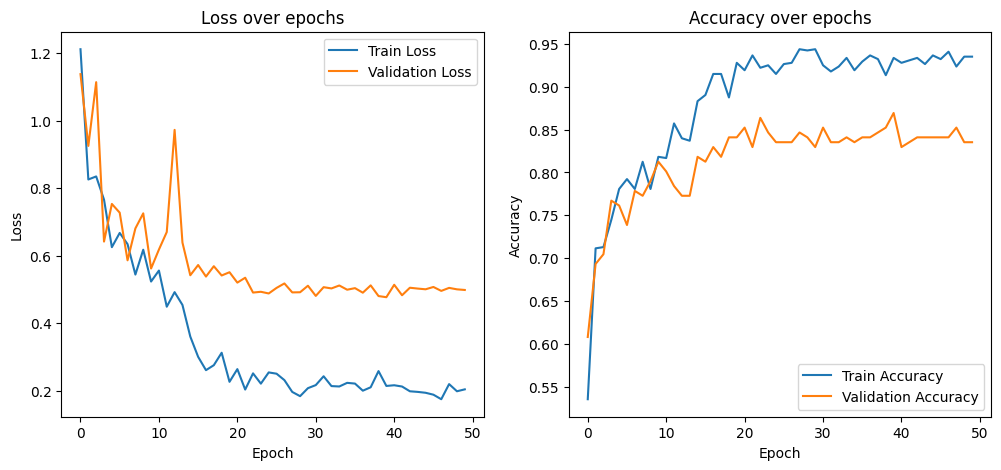

Final model saved.

Evaluating on validation set...

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.74      0.87      0.80        39
            Clean       0.83      0.90      0.86        39
            Dusty       0.90      0.68      0.78        38
Electrical-damage       0.91      0.95      0.93        21
  Physical-Damage       0.83      0.71      0.77        14
     Snow-Covered       0.88      0.88      0.88        25

         accuracy                           0.84       176
        macro avg       0.85      0.83      0.84       176
     weighted avg       0.84      0.84      0.83       176



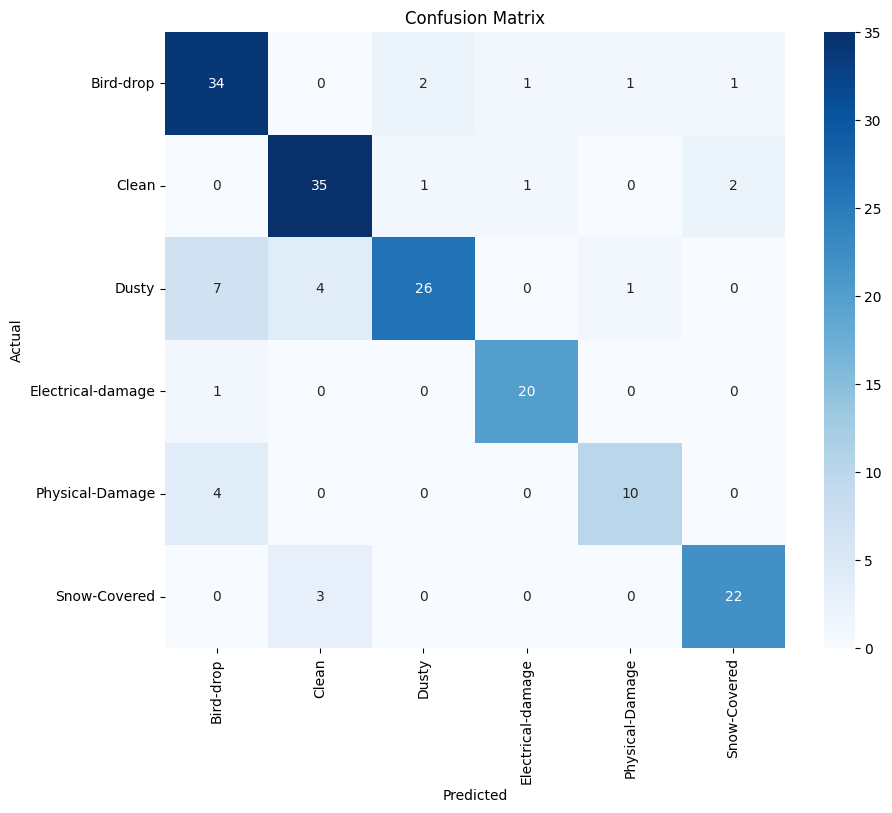


Solar Panel Analysis:
---------------------
Status: Good
Confidence: 99.94%


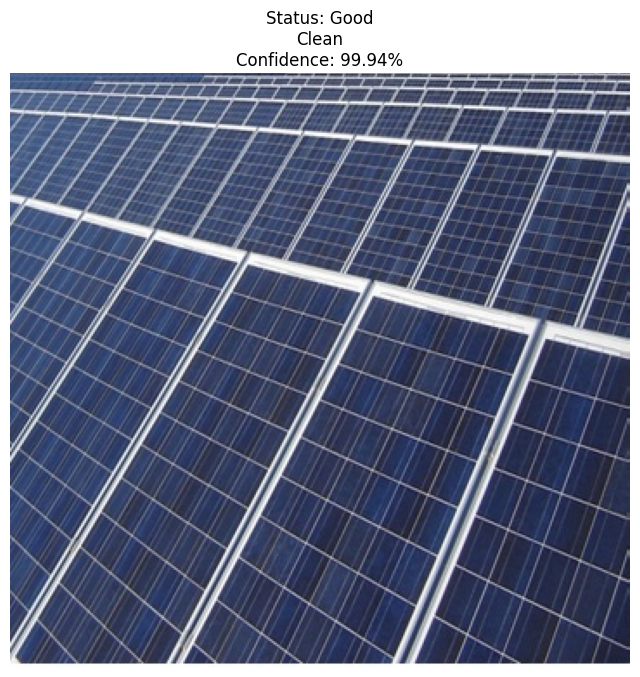

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
from shutil import copyfile
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Dataset parameters
data_dir = '/content/drive/MyDrive/Faulty_solar_panel'  # Root directory of your dataset
classes = ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
num_classes = len(classes)

# Hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 50

# Data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Function to create train/val split if they don't exist
def create_train_val_split(data_dir, classes):
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')

    if not os.path.exists(train_dir) or not os.path.exists(val_dir):
        print("Creating train/validation split...")
        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(val_dir, exist_ok=True)

        for class_name in classes:
            class_dir = os.path.join(data_dir, class_name)
            if not os.path.exists(class_dir):
                continue

            # Create class subdirectories in train and val
            os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
            os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

            # Get all images for this class
            images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            # Split (80% train, 20% val)
            train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

            # Copy to train and val folders
            for img in train_images:
                src = os.path.join(class_dir, img)
                dst = os.path.join(train_dir, class_name, img)
                copyfile(src, dst)

            for img in val_images:
                src = os.path.join(class_dir, img)
                dst = os.path.join(val_dir, class_name, img)
                copyfile(src, dst)

        print("Train/validation split created successfully.")
    else:
        print("Train/validation folders already exist.")

# Create train/val split if needed
create_train_val_split(data_dir, classes)

# Load dataset
try:
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                    for x in ['train', 'val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=4)
                for x in ['train', 'val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
    class_names = image_datasets['train'].classes

    # Verify the classes match
    assert set(class_names) == set(classes), f"Folder names don't match expected classes. Found: {class_names}, Expected: {classes}"

except FileNotFoundError as e:
    print("\nError loading dataset:")
    print(e)
    print("\nAlternative approach: Creating dataset from single folder structure...")

    # Alternative approach if the above fails
    full_dataset = datasets.ImageFolder(data_dir, data_transforms['train'])

    # Split into train and val (80-20 split)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Apply different transforms to validation set
    val_dataset.dataset.transform = data_transforms['val']

    # Create dataloaders
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    }

    dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
    class_names = full_dataset.classes

    print(f"Successfully created dataset with {len(full_dataset)} images total")
    print(f"Training set size: {dataset_sizes['train']}")
    print(f"Validation set size: {dataset_sizes['val']}")
    print(f"Classes: {class_names}")

# Load pretrained GoogleNet
model = models.googlenet(pretrained=True)

# Modify the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

# Training function
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()
    best_model_wts = torch.load('best_model.pth') if os.path.exists('best_model.pth') else model.state_dict()
    best_acc = 0.0

    # Initialize lists to store metrics
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Store metrics
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())
                # Update learning rate based on validation accuracy
                scheduler.step(epoch_acc)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"New best model saved with val_acc: {best_acc:.4f}")

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_acc_history, label='Train Accuracy')
    plt.plot(val_acc_history, label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig('training_history.png')
    plt.show()

    return model

# Train the model
print("Starting training...")
model = train_model(model, criterion, optimizer, scheduler, num_epochs)

# Save the final model
torch.save(model.state_dict(), 'final_model.pth')
print("Final model saved.")

# Evaluation function
def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()

    return all_preds, all_labels, all_probs

# Evaluate on validation set
print("\nEvaluating on validation set...")
val_preds, val_labels, val_probs = evaluate_model(model, dataloaders['val'], class_names)

# Prediction function for single image
def predict_solar_panel(image_path, model, class_names, threshold=0.5):
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_t = data_transforms['val'](img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        probabilities = torch.softmax(outputs, dim=1)

    # Get results
    predicted_idx = preds.item()
    predicted_class = class_names[predicted_idx]
    confidence = probabilities[0][predicted_idx].item()

    # Determine if good or bad (assuming 'Clean' is the only good class)
    status = "Good" if predicted_class == "Clean" else "Bad"

    # Print results
    print("\nSolar Panel Analysis:")
    print("---------------------")
    print(f"Status: {status}")
    if status == "Bad":
        print(f"Damage Type: {predicted_class}")
    print(f"Confidence: {confidence*100:.2f}%")

    # Print all probabilities if confidence is low
    if confidence < threshold:
        print("\nDetailed Probabilities:")
        for i, prob in enumerate(probabilities[0]):
            print(f"{class_names[i]}: {prob.item()*100:.2f}%")

    # Show image with prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Status: {status}\n{predicted_class if status=='Bad' else 'Clean'}\nConfidence: {confidence*100:.2f}%")
    plt.axis('off')
    plt.show()

    return {
        'status': status,
        'damage_type': predicted_class if status == "Bad" else None,
        'confidence': confidence,
        'all_probabilities': {class_names[i]: prob.item() for i, prob in enumerate(probabilities[0])}
    }

# Example usage
test_image_path = "/content/drive/MyDrive/Faulty_solar_panel/Clean/Clean (2).jpg"
result = predict_solar_panel(test_image_path, model, class_names)